In [137]:
import pandas as pd
from data_handling import MassBalance
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor 
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from scipy.stats import gaussian_kde as kde
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']

site_dict = {'wolverine':['N','B','EC'],
                'kahiltna':['K53','K17b'], # 'K14k',
                'kennicott':['GTL','GTH','KC31'],
                'lemon_creek':['B','C','D'],
                'taku':['NWB1','MG1','TKG3'],
                'gulkana':['AU','B','D']
                }

In [138]:
# get list of sites in ablation and accumulation area based on measured annual mass balance
list_accumulation = []
list_ablation = []

for glacier in site_dict:
    for site in site_dict[glacier]:
        data = MassBalance(glacier, site, use='benchmark annual')
        if np.mean(data.data) > 0:
            list_accumulation.append(glacier+site)
        else:
            list_ablation.append(glacier+site)

# list potential distinctions to perform regression on
all_groups = {
          'all':['gulkana','wolverine','taku','kennicott','kahiltna','lemon_creek'], 
          'coastal':['wolverine','taku','lemon_creek'],
          'continental':['gulkana','kennicott','kahiltna'],
          'accumulation_area':list_accumulation,
          'ablation_area':list_ablation
          }

## FIRST: HOURLY

In [139]:
group = 'coastal'

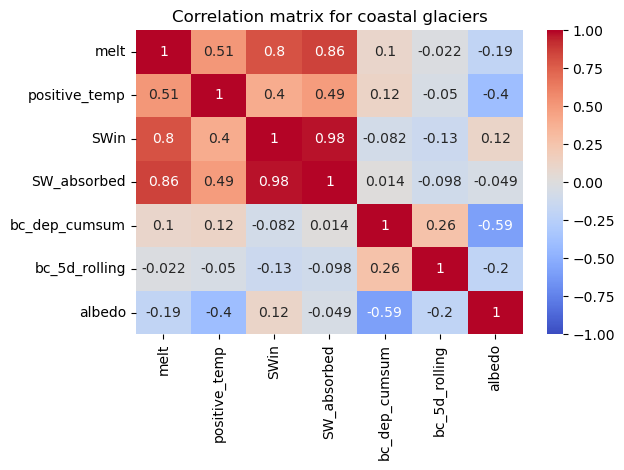

In [140]:
# open dataframe processed in `get_ddf.py` containing hourly data for all sites
all_df = pd.read_csv(base_fp+'ddf/all_hourly_df.csv')
if group in ['all','coastal','continental']:
    glac_df = all_df.loc[all_df['glacier'].isin(all_groups[group])].copy()
else:
    glac_df = all_df.loc[all_df['glaciersite'].isin(all_groups[group])].copy()
glac_df['SW_absorbed'] = glac_df['SWin'] * (1-glac_df['albedo'])
corr = glac_df[['melt','positive_temp','SWin','SW_absorbed','bc_dep_cumsum','bc_5d_rolling','albedo']].corr()
plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title(f'Correlation matrix for {group} glaciers')
plt.tight_layout()
plt.show()

### 1. Air temperature and black carbon deposition (simplest)
$melt=f_{T}*T_++f_{BC}*BC_{5d}$

                                 OLS Regression Results                                
Dep. Variable:                   melt   R-squared (uncentered):                   0.726
Model:                            OLS   Adj. R-squared (uncentered):              0.726
Method:                 Least Squares   F-statistic:                          5.580e+05
Date:                Thu, 26 Mar 2026   Prob (F-statistic):                        0.00
Time:                        16:49:58   Log-Likelihood:                     -5.2411e+05
No. Observations:              421743   AIC:                                  1.048e+06
Df Residuals:                  421741   BIC:                                  1.048e+06
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

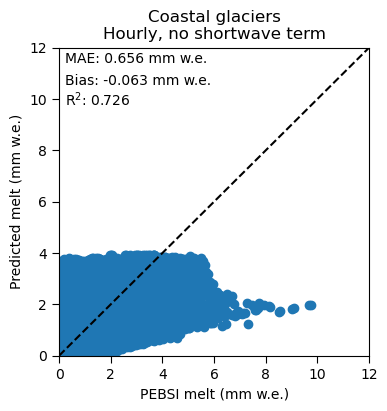

In [141]:
regression_vars = ['positive_temp','bc_5d_rolling']

# define variables for regression
X = glac_df[regression_vars] # 
y = glac_df['melt']

# train OLS model
model = sm.OLS(y, X).fit()
print(model.summary())

# extract model parameters
factors = [model.params[factor] for factor in regression_vars]

# evaluate the predicted melt
melt_predicted = np.sum(X * factors, axis=1)
melt_actual = glac_df['melt']

# build stack for KDE plot
x = melt_actual.values
y = melt_predicted.values
# xy = np.vstack([x, y])
# z = kde(xy)(xy)
# idx = z.argsort()
# x, y, z = x[idx], y[idx], z[idx]

# scatterplot of predictions on 1:1 space
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(melt_actual, melt_predicted) # , c=z, cmap='magma')
ax.plot([0,12],[0,12],'k--')

# beautify
# ax.legend()
ax.tick_params(length=5)
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.set_xlabel('PEBSI melt (mm w.e.)')
ax.set_ylabel('Predicted melt (mm w.e.)')
# ax.set_title(f'{group.capitalize()} glaciers\n$melt={ddf:.3f}*T_++{bcf:.2e}*'.replace('e+0','e')+r'BC_{5d}$')

# add error metrics
mae = np.nanmean(np.abs(melt_predicted - melt_actual))
bias = np.nanmean(melt_predicted - melt_actual)
r2 = model.rsquared
ax.text(0.02, 0.95, f'MAE: {mae:.3f} mm w.e.', transform=ax.transAxes)
ax.text(0.02, 0.88, f'Bias: {bias:.3f} mm w.e.', transform=ax.transAxes)
ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)
ax.set_title(f'{group.capitalize()} glaciers\nHourly, no shortwave term')
plt.show()

In [142]:
factors

[np.float64(0.15776744045729157), np.float64(76959.48349057752)]

$f_T=0.150 \text{ mm w.e. } ^{\circ}\text{C}^{-1}$ 

$f_{BC}=67431 \text{ mm w.e. kg}_{BC}^{-1} \text{ m}^2$

### 2. Air temperature, albedo, incoming SW (ETI similar to Pelliciotti, 2005)
$melt=f_T*T_++f_{SW}(1-\alpha)SW_{in}$

$ f_T, f_{SW} $ are calibrated and
$ \alpha = f(BC_{5d}) $

Can test different ways of modeling albedo here using air temperature, black carbon deposition, days since accumulation?

1. Machine learning
2. Linear regression

                                 OLS Regression Results                                
Dep. Variable:                   melt   R-squared (uncentered):                   0.906
Model:                            OLS   Adj. R-squared (uncentered):              0.906
Method:                 Least Squares   F-statistic:                          2.030e+06
Date:                Thu, 26 Mar 2026   Prob (F-statistic):                        0.00
Time:                        16:49:59   Log-Likelihood:                     -2.9855e+05
No. Observations:              421743   AIC:                                  5.971e+05
Df Residuals:                  421741   BIC:                                  5.971e+05
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

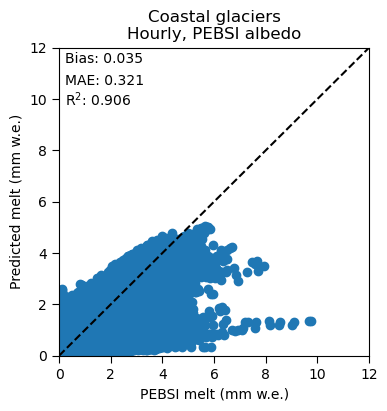

In [143]:
regression_vars = ['positive_temp','absorbed_SW']

# first calculate column for the (1-a)SWin term
glac_df['absorbed_SW'] = (1-glac_df['albedo']) * glac_df['SWin']

# perform regression on f_T and f_SW
X = glac_df[regression_vars]
y = glac_df['melt']

# show how well this regression on its own does
model = sm.OLS(y, X).fit()
print(model.summary())

# extract model parameters
factors = [model.params[factor] for factor in regression_vars]

# evaluate the predicted melt
melt_predicted = np.sum(X * factors, axis=1)
melt_actual = glac_df['melt']

# scatterplot of predictions on 1:1 space
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(melt_actual, melt_predicted) # , c=z, cmap='magma')
ax.plot([0,12],[0,12],'k--')

# get error metrics
meas = np.array(melt_actual).ravel()
mod = np.array(melt_predicted).ravel()
bias = np.nanmean(meas - mod)
mae = np.nanmean(np.abs(meas - mod))
r2 = 1 - np.sum(np.square(meas - mod)) / np.sum(np.square(meas)) #  - np.mean(meas)))

# add error metrics
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

# beautify
# ax.legend()
ax.tick_params(length=5)
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.set_xlabel('PEBSI melt (mm w.e.)')
ax.set_ylabel('Predicted melt (mm w.e.)')
ax.set_title(f'{group.capitalize()} glaciers\nHourly, PEBSI albedo')
plt.show()

In [144]:
factors

[np.float64(0.045474987890086686), np.float64(0.007326981020427079)]

$f_T=0.0354 \text{ mm w.e. } ^{\circ}\text{C}^{-1}$ 

$f_{SW}=0.00750 \text{ mm w.e. W}^{-1} \text{ m}^2$

Random forest regressor to get:

$\alpha_{pred}=f(T_+, BC_{cumsum})$


Then predict melt using the model coefficients determined from modeled albedo

$melt=f_T*T_++f_{SW}(1-\alpha_{pred})SW_{in}$


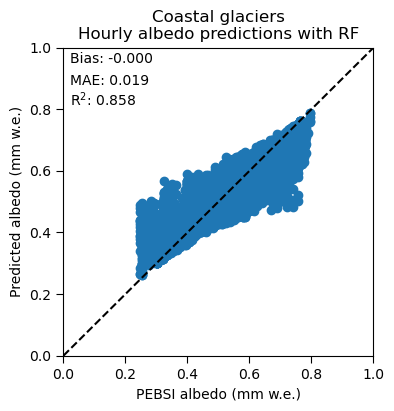

In [145]:
# test getting albedo from other variables
albedo_regression_vars = ['positive_temp','bc_dep_cumsum']

# perform regression on f_T and f_SW
X = glac_df[albedo_regression_vars]
y = glac_df['albedo']

# show how well this regression on its own does
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

albedo_model = RandomForestRegressor(n_estimators=100, n_jobs=-1, max_depth = 20, random_state=42)
albedo_model.fit(X_train, y_train)

# evaluate the predicted melt
albedo_predicted = albedo_model.predict(X_train)
albedo_actual = y_train

# get error metrics
meas = np.array(albedo_actual).ravel()
mod = np.array(albedo_predicted).ravel()
bias = np.nanmean(meas - mod)
mae = np.nanmean(np.abs(meas - mod))
r2 = 1 - np.sum(np.square(meas - mod)) / np.sum(np.square(meas - np.mean(meas)))

# scatterplot of predictions on 1:1 space
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(albedo_actual, albedo_predicted) # , c=z, cmap='magma')
ax.plot([0,1],[0,1],'k--')

# add error metrics
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

# beautify
# ax.legend()
ax.tick_params(length=5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('PEBSI albedo (mm w.e.)')
ax.set_ylabel('Predicted albedo (mm w.e.)')
ax.set_title(f'{group.capitalize()} glaciers\nHourly albedo predictions with RF')
plt.show()

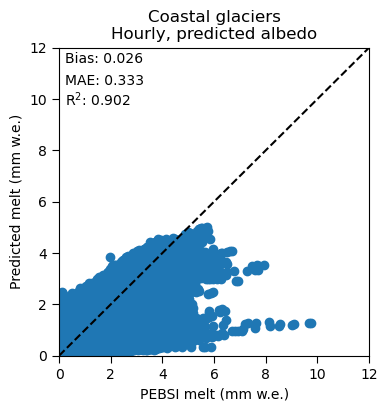

In [146]:
# apply the same regression from before on the predicted albedo values
glac_df['albedo_ml'] = albedo_model.predict(glac_df[albedo_regression_vars])

# first calculate column for the (1-a)SWin term
glac_df['absorbed_SW_ml'] = (1-glac_df['albedo_ml']) * glac_df['SWin']

# build new X from predicted albedo
regression_vars = ['positive_temp','absorbed_SW_ml']
X = glac_df[regression_vars]

# evaluate the predicted melt
melt_predicted = np.sum(X * factors, axis=1)
melt_actual = glac_df['melt']

# scatterplot of predictions on 1:1 space
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(melt_actual, melt_predicted) # , c=z, cmap='magma')
ax.plot([0,12],[0,12],'k--')

# get error metrics
meas = np.array(melt_actual).ravel()
mod = np.array(melt_predicted).ravel()
bias = np.nanmean(meas - mod)
mae = np.nanmean(np.abs(meas - mod))
r2 = 1 - np.sum(np.square(meas - mod)) / np.sum(np.square(meas)) #  - np.mean(meas)))

# add error metrics
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

# beautify
# ax.legend()
ax.tick_params(length=5)
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.set_xlabel('PEBSI melt (mm w.e.)')
ax.set_ylabel('Predicted melt (mm w.e.)')
ax.set_title(f'{group.capitalize()} glaciers\nHourly, predicted albedo')
plt.show()

## DAILY

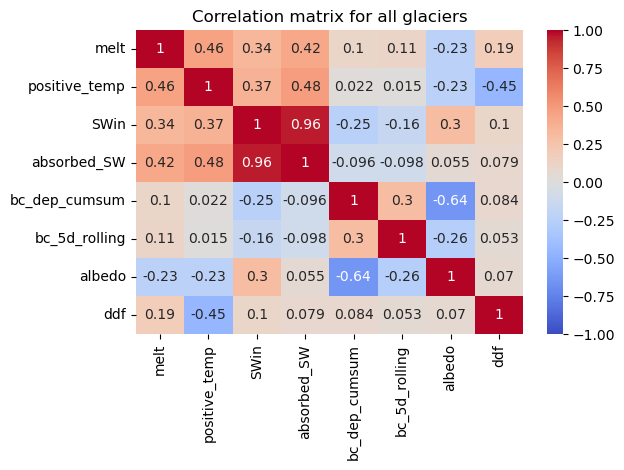

In [147]:
# open dataframe processed in `get_ddf.py` containing hourly data for all sites
all_df = pd.read_csv(base_fp+'ddf/all_daily_df.csv')
if group in ['all','coastal','continental']:
    glac_df = all_df.loc[all_df['glacier'].isin(all_groups[group])].copy()
else:
    glac_df = all_df.loc[all_df['glaciersite'].isin(all_groups[group])].copy()

glac_df = glac_df.rename(columns={'pdds_1d_rolling':'positive_temp'})
glac_df['absorbed_SW'] = glac_df['SWin'] * (1-glac_df['albedo'])
corr = glac_df[['melt','positive_temp','SWin','absorbed_SW','bc_dep_cumsum','bc_5d_rolling','albedo','ddf']].corr()
plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title(f'Correlation matrix for all glaciers')
plt.tight_layout()
plt.show()

                                 OLS Regression Results                                
Dep. Variable:                   melt   R-squared (uncentered):                   0.869
Model:                            OLS   Adj. R-squared (uncentered):              0.869
Method:                 Least Squares   F-statistic:                          5.047e+04
Date:                Thu, 26 Mar 2026   Prob (F-statistic):                        0.00
Time:                        16:59:56   Log-Likelihood:                         -53583.
No. Observations:               15239   AIC:                                  1.072e+05
Df Residuals:                   15237   BIC:                                  1.072e+05
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

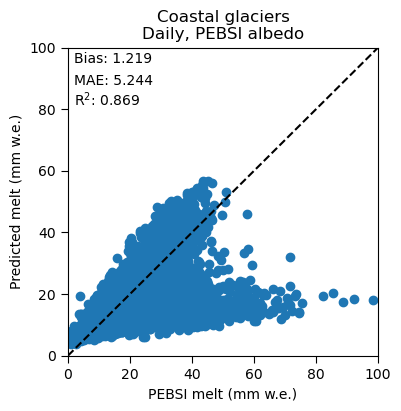

In [161]:
regression_vars = ['positive_temp','absorbed_SW']

# perform regression on f_T and f_SW
X = glac_df[regression_vars]
y = glac_df['melt']

# show how well this regression on its own does
model = sm.OLS(y, X).fit()
print(model.summary())

# extract model parameters
factors = [model.params[factor] for factor in regression_vars]

# evaluate the predicted melt
melt_predicted = np.sum(X * factors, axis=1)
melt_actual = glac_df['melt']

# scatterplot of predictions on 1:1 space
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(melt_actual, melt_predicted) # , c=z, cmap='magma')
ax.plot([0,100],[0,100],'k--')

# get error metrics
meas = np.array(melt_actual).ravel()
mod = np.array(melt_predicted).ravel()
bias = np.nanmean(meas - mod)
mae = np.nanmean(np.abs(meas - mod))
r2 = 1 - np.sum(np.square(meas - mod)) / np.sum(np.square(meas)) #  - np.mean(meas)))

# add error metrics
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

# beautify
# ax.legend()
ax.tick_params(length=5)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xlabel('PEBSI melt (mm w.e.)')
ax.set_ylabel('Predicted melt (mm w.e.)')
ax.set_title(f'{group.capitalize()} glaciers\nDaily, PEBSI albedo')
plt.show()

$f_T=1.343 \text{ mm w.e. } ^{\circ}\text{C}^{-1}$ 

$f_{SW}=1.431\times10^{-6} \text{ mm w.e. J}^{-1} \text{ m}^2$

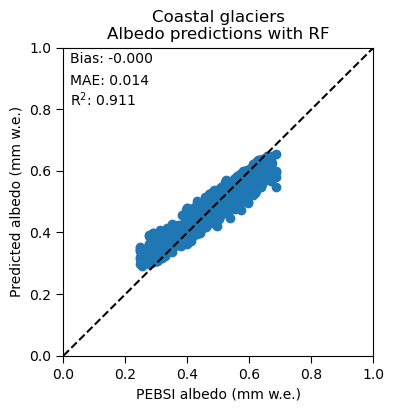

In [150]:
# test getting albedo from other variables
albedo_regression_vars = ['positive_temp','bc_dep_cumsum']

# perform regression on f_T and f_SW
X = glac_df[albedo_regression_vars]
y = glac_df['albedo']

# show how well this regression on its own does
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

albedo_model = RandomForestRegressor(n_estimators=100, n_jobs=-1, max_depth = 20, random_state=42)
albedo_model.fit(X_train, y_train)

# evaluate the predicted melt
albedo_predicted = albedo_model.predict(X_train)
albedo_actual = y_train

# get error metrics
meas = np.array(albedo_actual).ravel()
mod = np.array(albedo_predicted).ravel()
bias = np.nanmean(meas - mod)
mae = np.nanmean(np.abs(meas - mod))
r2 = 1 - np.sum(np.square(meas - mod)) / np.sum(np.square(meas - np.mean(meas)))

# scatterplot of predictions on 1:1 space
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(albedo_actual, albedo_predicted) # , c=z, cmap='magma')
ax.plot([0,1],[0,1],'k--')

# add error metrics
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

# beautify
# ax.legend()
ax.tick_params(length=5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('PEBSI albedo (mm w.e.)')
ax.set_ylabel('Predicted albedo (mm w.e.)')
ax.set_title(f'{group.capitalize()} glaciers\nAlbedo predictions with RF')
plt.show()

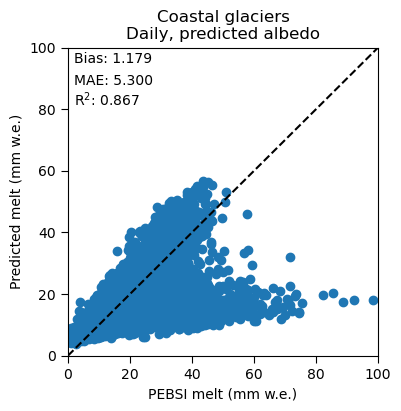

In [ ]:
# apply the same regression from before on the predicted albedo values
glac_df['albedo_ml'] = albedo_model.predict(glac_df[albedo_regression_vars])

# first calculate column for the (1-a)SWin term
glac_df['absorbed_SW_ml'] = (1-glac_df['albedo_ml']) * glac_df['SWin']

# build new X from predicted albedo
regression_vars = ['positive_temp','absorbed_SW_ml']
X = glac_df[regression_vars]

# evaluate the predicted melt
melt_predicted = np.sum(X * factors, axis=1)
melt_actual = glac_df['melt']

# scatterplot of predictions on 1:1 space
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(melt_actual, melt_predicted) # , c=z, cmap='magma')
ax.plot([0,100],[0,100],'k--')

# get error metrics
meas = np.array(melt_actual).ravel()
mod = np.array(melt_predicted).ravel()
bias = np.nanmean(meas - mod)
mae = np.nanmean(np.abs(meas - mod))
r2 = 1 - np.sum(np.square(meas - mod)) / np.sum(np.square(meas)) #  - np.mean(meas)))

# add error metrics
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

# beautify
# ax.legend()
ax.tick_params(length=5)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xlabel('PEBSI melt (mm w.e.)')
ax.set_ylabel('Predicted melt (mm w.e.)')
ax.set_title(f'{group.capitalize()} glaciers\nDaily, predicted albedo')
plt.show()

                                 OLS Regression Results                                
Dep. Variable:                   melt   R-squared (uncentered):                   0.926
Model:                            OLS   Adj. R-squared (uncentered):              0.926
Method:                 Least Squares   F-statistic:                          6.381e+04
Date:                Thu, 26 Mar 2026   Prob (F-statistic):                        0.00
Time:                        17:00:32   Log-Likelihood:                         -49194.
No. Observations:               15239   AIC:                                  9.839e+04
Df Residuals:                   15236   BIC:                                  9.842e+04
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

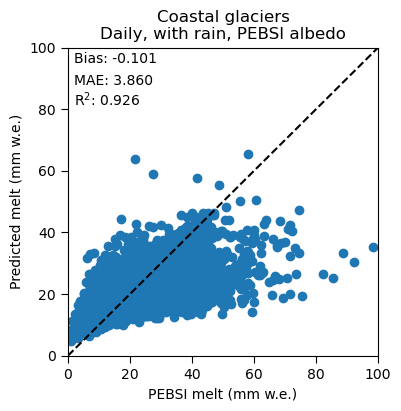

In [163]:
regression_vars = ['positive_temp','absorbed_SW','rain']

# perform regression on f_T and f_SW
X = glac_df[regression_vars]
y = glac_df['melt']

# show how well this regression on its own does
model = sm.OLS(y, X).fit()
print(model.summary())

# extract model parameters
factors = [model.params[factor] for factor in regression_vars]

# evaluate the predicted melt
melt_predicted = np.sum(X * factors, axis=1)
melt_actual = glac_df['melt']

# scatterplot of predictions on 1:1 space
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(melt_actual, melt_predicted) # , c=z, cmap='magma')
ax.plot([0,100],[0,100],'k--')

# get error metrics
meas = np.array(melt_actual).ravel()
mod = np.array(melt_predicted).ravel()
bias = np.nanmean(meas - mod)
mae = np.nanmean(np.abs(meas - mod))
r2 = 1 - np.sum(np.square(meas - mod)) / np.sum(np.square(meas)) #  - np.mean(meas)))

# add error metrics
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

# beautify
# ax.legend()
ax.tick_params(length=5)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xlabel('PEBSI melt (mm w.e.)')
ax.set_ylabel('Predicted melt (mm w.e.)')
ax.set_title(f'{group.capitalize()} glaciers\nDaily, with rain, PEBSI albedo')
plt.show()